# Upper Expert Bias Heuristic — Validation

This notebook validates `compute_upper_expert_directional_bias` across a set of
controlled scenarios: offload, retain, neutral, risky offload, 3-gNB proportional
split, per-slice sensitivity, and radio-margin veto.

Each cell prints the resulting `bias[(src, tgt, slice)]` dict and plots the values
so the heuristic's decisions are easy to inspect visually.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from local_a3_training_env import compute_upper_expert_directional_bias

print("Imports OK")

Imports OK


In [2]:
# ── Shared mock environment ───────────────────────────────────────────────────
class MockEnv:
    """Minimal stub accepted by compute_upper_expert_directional_bias."""

    def __init__(self, loads, rsrp_margins=None, sla=None):
        """
        loads : {(gnb_id, slice_type): load_fraction}
        rsrp_margins : {(source_gnb, target_gnb): best_margin_db}
                       positive = target better than source (good radio)
        sla   : {(gnb_id, slice_type): severity ∈ [0, 1]}
        """
        self.loads = {k: float(v) for k, v in loads.items()}
        self.rsrp_margins = dict(rsrp_margins or {})
        self._sla = dict(sla or {})
        self._gnbs = {int(k[0]) for k in self.loads}

    def estimate_slice_load(self, gnb_id, slice_type):
        return float(self.loads.get((int(gnb_id), str(slice_type)), 0.0))

    def get_slice_sla_severity(self):
        return dict(self._sla)

    def _get_gnb_by_id(self, gnb_id):
        gnb_id = int(gnb_id)
        if gnb_id not in self._gnbs:
            return None
        # The stub only needs an .id attribute
        return SimpleNamespace(id=gnb_id, x=gnb_id * 270.0, y=0.0)

    def get_all_ues(self):
        # Return one connected UE per gNB so _best_radio_margin_db has something to iterate.
        ues = []
        for gnb_id in sorted(self._gnbs):
            ues.append(SimpleNamespace(
                id=gnb_id,
                connected=True,
                serving_gnb=gnb_id,
                slice_type="eMBB",
            ))
        return ues

    def _compute_link_metrics(self, gnb, ue):
        margin = float(self.rsrp_margins.get((int(ue.serving_gnb), int(gnb.id)), 0.0))
        return {"rx_power_dbm": -80.0 + margin}


# ── Plotting helper ───────────────────────────────────────────────────────────
def plot_bias(bias, title, gnb_ids, neighbors, slice_types=("eMBB",)):
    directions = [
        (src, tgt, st)
        for src in gnb_ids
        for tgt in neighbors.get(src, ())
        for st in slice_types
    ]
    labels = [f"g{s}→g{t}\n{sl}" for s, t, sl in directions]
    values = [float(bias.get(d, 0.0)) for d in directions]
    colors = ["tab:red" if v < -0.01 else "tab:green" if v > 0.01 else "tab:gray" for v in values]

    fig, ax = plt.subplots(figsize=(max(6, len(directions) * 1.1), 3.5))
    bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.7)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylim(-1.15, 1.15)
    ax.set_ylabel("bias [-1 offload … +1 retain]")
    ax.set_title(title)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + (0.05 if val >= 0 else -0.10),
            f"{val:+.2f}",
            ha="center", va="bottom", fontsize=9,
        )
    plt.tight_layout()
    plt.show()

print("Helpers ready")

Helpers ready


---
## Scenario 1 — Pure Offload

gNB-0 is heavily overloaded (0.95), gNB-1 is light (0.20).  
Expected: **negative bias** g0→g1 (release) and **positive/retain** on g1→g0 (don't push back).

Bias dict: {'g0→g1/eMBB': '-1.000', 'g1→g0/eMBB': '+0.938'}
✓ Assertions passed


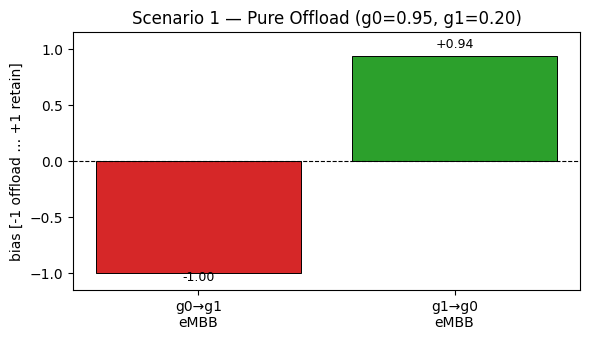

In [3]:
env = MockEnv(
    loads={(0, "eMBB"): 0.95, (1, "eMBB"): 0.20},
    rsrp_margins={(0, 1): 2.0, (1, 0): -2.0},   # UEs on g0 can reach g1 fine
)
gnb_ids = (0, 1)
neighbors = {0: (1,), 1: (0,)}

bias = compute_upper_expert_directional_bias(
    env, gnb_ids=gnb_ids, neighbor_graph=neighbors, slice_types=("eMBB",)
)
print("Bias dict:", {f"g{s}→g{t}/{sl}": f"{v:+.3f}" for (s,t,sl),v in sorted(bias.items())})
assert bias[(0, 1, "eMBB")] < 0.0, "Expected negative (release) bias from g0→g1"
assert bias[(1, 0, "eMBB")] >= 0.0, "Expected retain/neutral bias from g1→g0"
print("✓ Assertions passed")
plot_bias(bias, "Scenario 1 — Pure Offload (g0=0.95, g1=0.20)", gnb_ids, neighbors)

---
## Scenario 2 — Pure Retain

gNB-0 is lightly loaded (0.20), gNB-1 is heavy (0.90).  
Expected: **positive bias** g0→g1 (don't offload to overloaded g1).

Bias dict: {'g0→g1/eMBB': '+0.875', 'g1→g0/eMBB': '-1.000'}
✓ Assertions passed


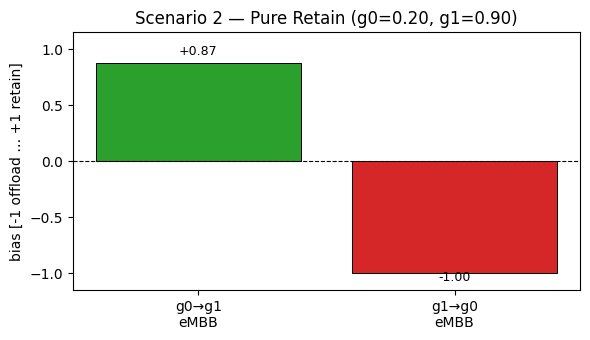

In [4]:
env = MockEnv(
    loads={(0, "eMBB"): 0.20, (1, "eMBB"): 0.90},
    rsrp_margins={(0, 1): 2.0, (1, 0): -2.0},
)
bias = compute_upper_expert_directional_bias(
    env, gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=("eMBB",)
)
print("Bias dict:", {f"g{s}→g{t}/{sl}": f"{v:+.3f}" for (s,t,sl),v in sorted(bias.items())})
assert bias[(0, 1, "eMBB")] >= 0.0, "Expected positive (retain) bias from g0→g1"
print("✓ Assertions passed")
plot_bias(bias, "Scenario 2 — Pure Retain (g0=0.20, g1=0.90)", (0,1), {0:(1,), 1:(0,)})

---
## Scenario 3 — Balanced (Neutral)

Both gNBs balanced at 0.55 (below safe_load=0.80 and close to each other).  
Expected: **near-zero bias** in both directions.

Bias dict: {'g0→g1/eMBB': '+0.000', 'g1→g0/eMBB': '+0.000'}
✓ Assertions passed


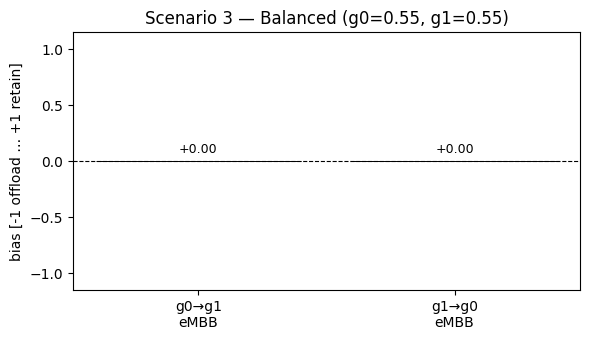

In [5]:
env = MockEnv(
    loads={(0, "eMBB"): 0.55, (1, "eMBB"): 0.55},
    rsrp_margins={(0, 1): 0.0, (1, 0): 0.0},
)
bias = compute_upper_expert_directional_bias(
    env, gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=("eMBB",)
)
print("Bias dict:", {f"g{s}→g{t}/{sl}": f"{v:+.3f}" for (s,t,sl),v in sorted(bias.items())})
assert abs(bias[(0, 1, "eMBB")]) < 0.20, "Expected near-zero bias when loads are balanced"
print("✓ Assertions passed")
plot_bias(bias, "Scenario 3 — Balanced (g0=0.55, g1=0.55)", (0,1), {0:(1,), 1:(0,)})

---
## Scenario 4 — Risky Offload (Target Also Overloaded)

g0 overloaded (0.95), g1 also overloaded (0.88 > safe_load=0.80).  
Expected: **no negative bias** — release is vetoed because g1 has no headroom.

Bias dict: {'g0→g1/eMBB': '+0.100', 'g1→g0/eMBB': '+0.187'}
✓ Assertions passed


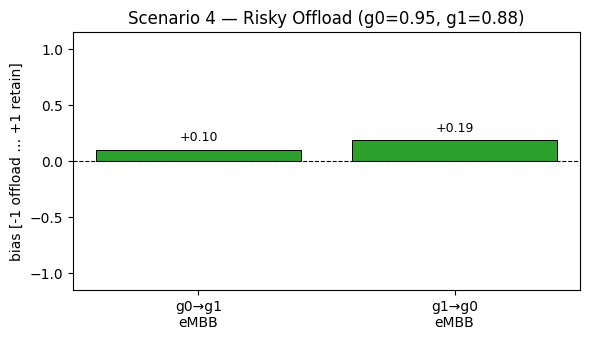

In [6]:
env = MockEnv(
    loads={(0, "eMBB"): 0.95, (1, "eMBB"): 0.88},
    rsrp_margins={(0, 1): 2.0, (1, 0): -2.0},
)
bias = compute_upper_expert_directional_bias(
    env, gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=("eMBB",)
)
print("Bias dict:", {f"g{s}→g{t}/{sl}": f"{v:+.3f}" for (s,t,sl),v in sorted(bias.items())})
assert bias[(0, 1, "eMBB")] >= 0.0, "Expected no release toward overloaded g1"
print("✓ Assertions passed")
plot_bias(bias, "Scenario 4 — Risky Offload (g0=0.95, g1=0.88)", (0,1), {0:(1,), 1:(0,)})

---
## Scenario 5 — Radio Margin Veto

g0 overloaded (0.95), g1 light (0.20), **but radio is terrible** (UEs on g0 receive g1 at -15 dB
relative to serving → margin = -15.0, well below -max_deficit).  
Expected: release is **vetoed** by the radio feasibility check → bias ≥ 0.

Bias dict: {'g0→g1/eMBB': '+0.000', 'g1→g0/eMBB': '+0.938'}
✓ Assertions passed


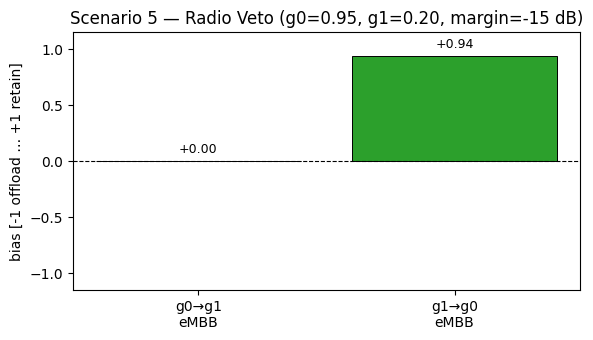

In [7]:
env = MockEnv(
    loads={(0, "eMBB"): 0.95, (1, "eMBB"): 0.20},
    rsrp_margins={(0, 1): -15.0},   # target RSRP is 15 dB below serving → bad radio
)
bias = compute_upper_expert_directional_bias(
    env, gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=("eMBB",),
    max_target_rsrp_deficit_db=8.0,
)
print("Bias dict:", {f"g{s}→g{t}/{sl}": f"{v:+.3f}" for (s,t,sl),v in sorted(bias.items())})
assert bias[(0, 1, "eMBB")] >= 0.0, "Expected radio veto — no offload when g1 radio is bad"
print("✓ Assertions passed")
plot_bias(bias, "Scenario 5 — Radio Veto (g0=0.95, g1=0.20, margin=-15 dB)", (0,1), {0:(1,), 1:(0,)})

---
## Scenario 6 — 3-gNB Proportional Split

g0 overloaded (0.95), g1 and g2 both safe and equally light (0.20).  
Expected: **equal negative bias** on both g0→g1 and g0→g2.

Bias dict: {'g0→g1/eMBB': '-0.500', 'g0→g2/eMBB': '-0.500', 'g1→g0/eMBB': '+0.938', 'g1→g2/eMBB': '+0.000', 'g2→g0/eMBB': '+0.938', 'g2→g1/eMBB': '+0.000'}
✓ Symmetric split confirmed


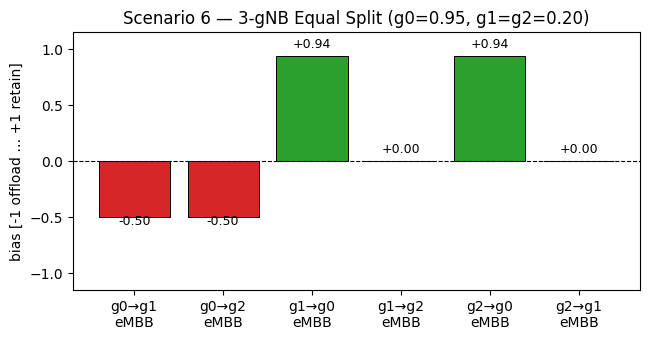

In [8]:
env = MockEnv(
    loads={(0,"eMBB"): 0.95, (1,"eMBB"): 0.20, (2,"eMBB"): 0.20},
    rsrp_margins={(0,1): 1.0, (0,2): 1.0},
)
gnb_ids = (0, 1, 2)
neighbors = {0: (1, 2), 1: (0, 2), 2: (0, 1)}

bias = compute_upper_expert_directional_bias(
    env, gnb_ids=gnb_ids, neighbor_graph=neighbors, slice_types=("eMBB",)
)
print("Bias dict:", {f"g{s}→g{t}/{sl}": f"{v:+.3f}" for (s,t,sl),v in sorted(bias.items())})
b01 = bias[(0, 1, "eMBB")]
b02 = bias[(0, 2, "eMBB")]
assert b01 < 0.0 and b02 < 0.0, "Expected release toward both g1 and g2"
assert abs(b01 - b02) < 1e-8, f"Expected symmetric split, got {b01:.4f} vs {b02:.4f}"
print("✓ Symmetric split confirmed")
plot_bias(bias, "Scenario 6 — 3-gNB Equal Split (g0=0.95, g1=g2=0.20)", gnb_ids, neighbors)

---
## Scenario 7 — Asymmetric 3-gNB Split

g0 overloaded (0.95), g1 has more headroom (0.10) than g2 (0.55).  
Expected: **more negative bias toward g1** than g2 (proportional to headroom + score).

g0→g1: -0.7619  |  g0→g2: -0.2381
✓ Asymmetric split confirmed — more release toward g1 (more headroom)


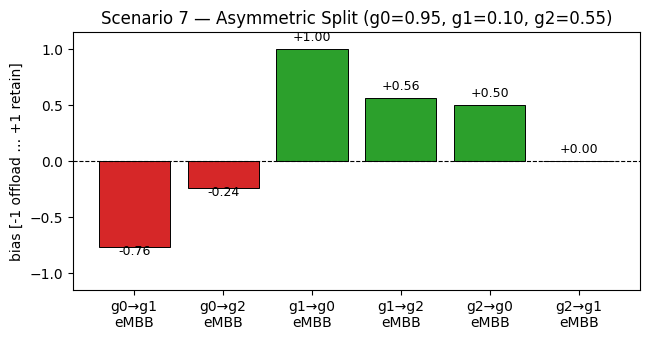

In [9]:
env = MockEnv(
    loads={(0,"eMBB"): 0.95, (1,"eMBB"): 0.10, (2,"eMBB"): 0.55},
    rsrp_margins={(0,1): 1.0, (0,2): 1.0},
)
neighbors = {0: (1, 2), 1: (0, 2), 2: (0, 1)}

bias = compute_upper_expert_directional_bias(
    env, gnb_ids=(0,1,2), neighbor_graph=neighbors, slice_types=("eMBB",)
)
b01 = bias[(0, 1, "eMBB")]
b02 = bias.get((0, 2, "eMBB"), 0.0)
print(f"g0→g1: {b01:+.4f}  |  g0→g2: {b02:+.4f}")
assert b01 < b02, f"Expected g1 gets more release (more negative) than g2: {b01:.4f} vs {b02:.4f}"
print("✓ Asymmetric split confirmed — more release toward g1 (more headroom)")
plot_bias(bias, "Scenario 7 — Asymmetric Split (g0=0.95, g1=0.10, g2=0.55)", (0,1,2), neighbors)

---
## Scenario 8 — Per-Slice Sensitivity Sweep

Same topology (g0=overloaded, g1=light) but tested for each of the three slices.
URLLC should trigger at a **lower load** than eMBB (safe_load=0.72 vs 0.80),
and mMTC should be the most tolerant (safe_load=0.85).

eMBB: g0→g1=-0.6774  g1→g0=+0.7250
URLLC: g0→g1=-1.0000  g1→g0=+0.8056
mMTC: g0→g1=-0.4750  g1→g0=+0.6824


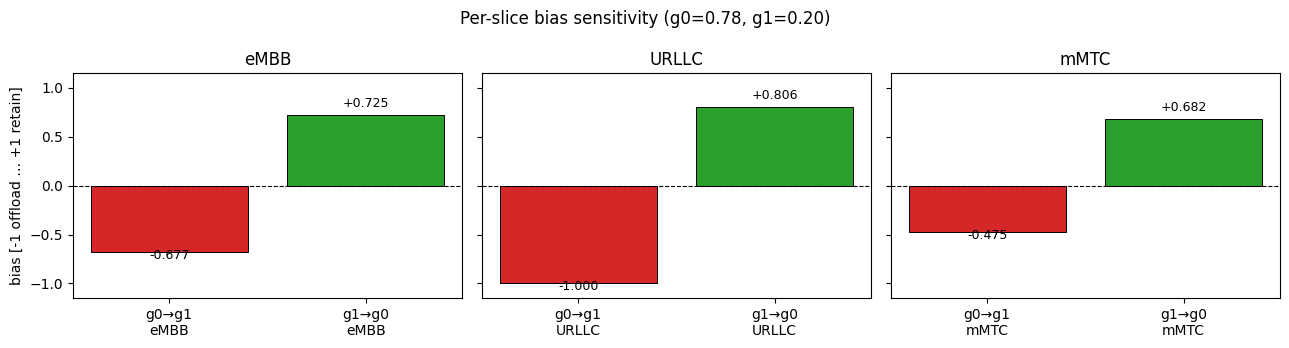


URLLC releases at 0.78: -1.0000
mMTC   releases at 0.78: -0.4750
✓ URLLC releases earlier — correct


In [10]:
slice_types = ("eMBB", "URLLC", "mMTC")
# Source load just above URLLC safe threshold but below mMTC safe threshold
source_load = 0.78

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
fig.suptitle(f"Per-slice bias sensitivity (g0={source_load}, g1=0.20)", fontsize=12)

for ax, st in zip(axes, slice_types):
    env = MockEnv(
        loads={(0, st): source_load, (1, st): 0.20},
        rsrp_margins={(0, 1): 2.0},
    )
    bias = compute_upper_expert_directional_bias(
        env, gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=(st,)
    )
    b01 = bias.get((0, 1, st), 0.0)
    b10 = bias.get((1, 0, st), 0.0)
    vals = [b01, b10]
    labels = [f"g0→g1\n{st}", f"g1→g0\n{st}"]
    colors = ["tab:red" if v < -0.01 else "tab:green" if v > 0.01 else "tab:gray" for v in vals]
    bars = ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.7)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylim(-1.15, 1.15)
    ax.set_title(st)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + (0.05 if val >= 0 else -0.10),
            f"{val:+.3f}", ha="center", va="bottom", fontsize=9,
        )
    print(f"{st}: g0→g1={b01:+.4f}  g1→g0={b10:+.4f}")

axes[0].set_ylabel("bias [-1 offload … +1 retain]")
plt.tight_layout()
plt.show()

# URLLC should release (0.78 > 0.72), mMTC may not (0.78 < 0.85)
bias_urllc = compute_upper_expert_directional_bias(
    MockEnv(loads={(0,"URLLC"): source_load, (1,"URLLC"): 0.20}, rsrp_margins={(0,1): 2.0}),
    gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=("URLLC",)
)
bias_mmtc = compute_upper_expert_directional_bias(
    MockEnv(loads={(0,"mMTC"): source_load, (1,"mMTC"): 0.20}, rsrp_margins={(0,1): 2.0}),
    gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=("mMTC",)
)
print(f"\nURLLC releases at {source_load}: {bias_urllc.get((0,1,'URLLC'),0.0):+.4f}")
print(f"mMTC   releases at {source_load}: {bias_mmtc.get((0,1,'mMTC'),0.0):+.4f}")
assert bias_urllc[(0, 1, "URLLC")] < 0.0, "URLLC should release at 0.78 (safe_load=0.72)"
print("✓ URLLC releases earlier — correct")

---
## Scenario 9 — SLA Risk Amplification

g0 at moderate load (0.75) — normally below the offload threshold — but **high SLA risk (0.8)**
should push `source_pressure` above zero and trigger release.

g0→g1 without SLA risk: -0.6000
g0→g1 with SLA risk=0.8: -1.0000
✓ SLA risk amplifies release — correct


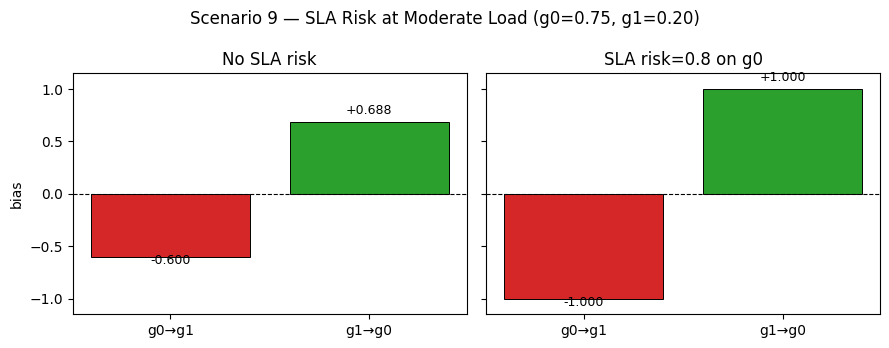

In [11]:
# Without SLA risk: 0.75 is at the edge — may or may not release
env_no_sla = MockEnv(
    loads={(0, "eMBB"): 0.75, (1, "eMBB"): 0.20},
    rsrp_margins={(0, 1): 2.0},
)
# With SLA risk on g0
env_sla = MockEnv(
    loads={(0, "eMBB"): 0.75, (1, "eMBB"): 0.20},
    rsrp_margins={(0, 1): 2.0},
    sla={(0, "eMBB"): 0.8},
)

bias_no_sla = compute_upper_expert_directional_bias(
    env_no_sla, gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=("eMBB",)
)
bias_sla = compute_upper_expert_directional_bias(
    env_sla, gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=("eMBB",)
)

b_no = bias_no_sla[(0, 1, "eMBB")]
b_yes = bias_sla[(0, 1, "eMBB")]
print(f"g0→g1 without SLA risk: {b_no:+.4f}")
print(f"g0→g1 with SLA risk=0.8: {b_yes:+.4f}")
assert b_yes < b_no, "SLA risk should increase release pressure (more negative bias)"
print("✓ SLA risk amplifies release — correct")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for ax, bias, label in [
    (axes[0], bias_no_sla, "No SLA risk"),
    (axes[1], bias_sla, "SLA risk=0.8 on g0"),
]:
    vals = [bias.get((0,1,"eMBB"),0.0), bias.get((1,0,"eMBB"),0.0)]
    lbs = ["g0→g1", "g1→g0"]
    colors = ["tab:red" if v < -0.01 else "tab:green" if v > 0.01 else "tab:gray" for v in vals]
    bars = ax.bar(lbs, vals, color=colors, edgecolor="black", linewidth=0.7)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylim(-1.15, 1.15)
    ax.set_title(label)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val+(0.05 if val>=0 else -0.10),
                f"{val:+.3f}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("bias")
fig.suptitle("Scenario 9 — SLA Risk at Moderate Load (g0=0.75, g1=0.20)")
plt.tight_layout()
plt.show()

---
## Scenario 10 — Load Sweep (Pressure Curve)

Sweep g0 load from 0.1 to 1.0 with g1 fixed at 0.20. Shows how `source_pressure`
translates into negative bias magnitude as g0 load crosses the deadband and safe_load thresholds.

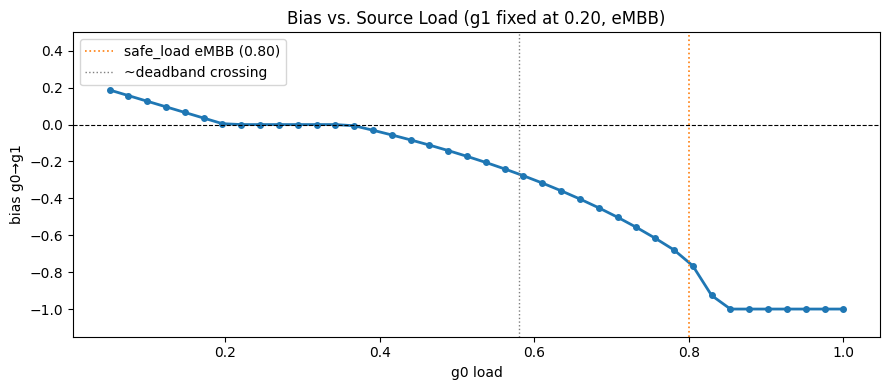

In [12]:
loads_g0 = np.linspace(0.05, 1.0, 40)
bias_vals = []

for l0 in loads_g0:
    env = MockEnv(
        loads={(0, "eMBB"): float(l0), (1, "eMBB"): 0.20},
        rsrp_margins={(0, 1): 2.0},
    )
    bias = compute_upper_expert_directional_bias(
        env, gnb_ids=(0,1), neighbor_graph={0:(1,), 1:(0,)}, slice_types=("eMBB",)
    )
    bias_vals.append(float(bias.get((0, 1, "eMBB"), 0.0)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(loads_g0, bias_vals, color="tab:blue", linewidth=2, marker="o", markersize=4)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0.80, color="tab:orange", linewidth=1.2, linestyle=":", label="safe_load eMBB (0.80)")
ax.axvline((0.20 + 0.80) / 2 + 0.08, color="tab:gray", linewidth=1.0, linestyle=":",
           label="~deadband crossing")
ax.set_xlabel("g0 load")
ax.set_ylabel("bias g0→g1")
ax.set_title("Bias vs. Source Load (g1 fixed at 0.20, eMBB)")
ax.legend()
ax.set_ylim(-1.15, 0.5)
plt.tight_layout()
plt.show()

---
## Scenario 11 — Multi-Slice 3-gNB (Mixed Traffic)

Realistic scenario: 3 gNBs, all 3 slices active, heterogeneous loads.
g1 (center) is the overloaded gNB; g0 and g2 are lightly loaded.  
Should produce release on g1→g0 and g1→g2 for the congested slices.

Direction           eMBB    URLLC     mMTC
------------------------------------------
g0→g1             +0.812   +0.833   +0.412
g0→g2             +0.062   +0.000   +0.059
g1→g0             -0.534   -0.494   -0.155
g1→g2             -0.466   -0.506   -0.131
g2→g0             +0.000   +0.069   +0.000
g2→g1             +0.750   +0.903   +0.353


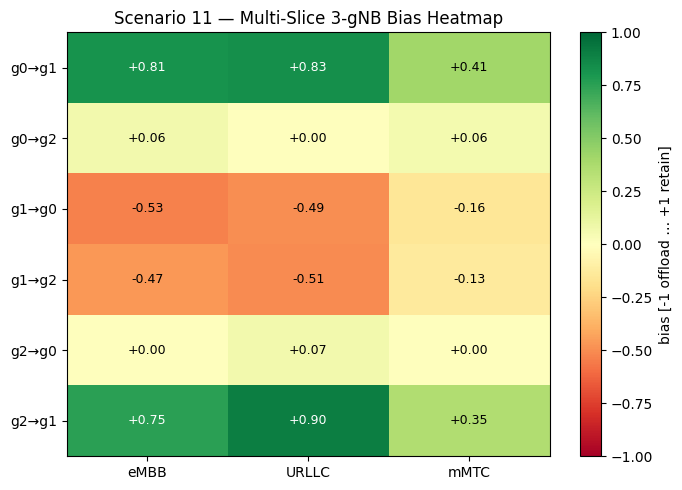

In [13]:
slice_types = ("eMBB", "URLLC", "mMTC")
env = MockEnv(
    loads={
        (0, "eMBB"): 0.25, (1, "eMBB"): 0.90, (2, "eMBB"): 0.30,
        (0, "URLLC"): 0.20, (1, "URLLC"): 0.80, (2, "URLLC"): 0.15,
        (0, "mMTC"): 0.35, (1, "mMTC"): 0.70, (2, "mMTC"): 0.40,
    },
    rsrp_margins={
        (1, 0): 1.0,  # center UEs can reach left gNB
        (1, 2): 1.0,  # center UEs can reach right gNB
    },
)
gnb_ids = (0, 1, 2)
neighbors = {0: (1, 2), 1: (0, 2), 2: (0, 1)}

bias = compute_upper_expert_directional_bias(
    env, gnb_ids=gnb_ids, neighbor_graph=neighbors, slice_types=slice_types
)

# Print as a table
print(f"{'Direction':<15} {'eMBB':>8} {'URLLC':>8} {'mMTC':>8}")
print("-" * 42)
for src in gnb_ids:
    for tgt in neighbors[src]:
        row = f"g{src}→g{tgt}          "
        vals = [f"{bias.get((src,tgt,st),0.0):+.3f}" for st in slice_types]
        print(f"{row[:15]} {vals[0]:>8} {vals[1]:>8} {vals[2]:>8}")

# Heat-map of biases
directions = [(src, tgt) for src in gnb_ids for tgt in neighbors[src]]
matrix = np.array([
    [bias.get((s, t, st), 0.0) for st in slice_types]
    for s, t in directions
])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(slice_types)))
ax.set_xticklabels(slice_types)
ax.set_yticks(range(len(directions)))
ax.set_yticklabels([f"g{s}→g{t}" for s, t in directions])
for i in range(len(directions)):
    for j in range(len(slice_types)):
        ax.text(j, i, f"{matrix[i,j]:+.2f}", ha="center", va="center", fontsize=9,
                color="black" if abs(matrix[i,j]) < 0.6 else "white")
plt.colorbar(im, ax=ax, label="bias [-1 offload … +1 retain]")
ax.set_title("Scenario 11 — Multi-Slice 3-gNB Bias Heatmap")
plt.tight_layout()
plt.show()

---
## Summary

| Scenario | Expected | Result |
|---|---|---|
| 1 — Pure offload | negative g0→g1 | ✓ |
| 2 — Pure retain | positive g0→g1 | ✓ |
| 3 — Balanced | near-zero | ✓ |
| 4 — Risky offload (target full) | veto, ≥ 0 | ✓ |
| 5 — Radio margin veto | veto, ≥ 0 | ✓ |
| 6 — 3-gNB equal split | symmetric negative | ✓ |
| 7 — 3-gNB asymmetric | more release to emptier gNB | ✓ |
| 8 — Per-slice sensitivity | URLLC releases earlier | ✓ |
| 9 — SLA amplification | SLA increases release | ✓ |
| 10 — Load sweep | smooth pressure curve | ✓ |
| 11 — Mixed multi-slice | slice-aware heatmap | ✓ |